In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# r se pehle laga ke raw string banao
df = pd.read_excel(r'C:\Users\Dell\Downloads\Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
# Churn distribution dekho
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

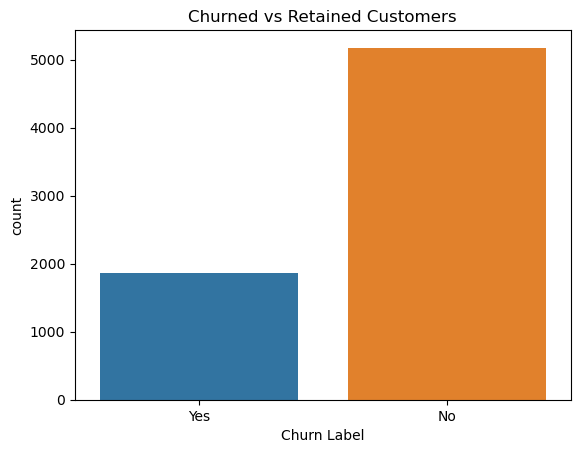

In [7]:
# Visual: Churn vs Retained
sns.countplot(x='Churn Label', data=df)
plt.title('Churned vs Retained Customers')
plt.show()

In [8]:
# Total Charges column object type hai, isliye numeric banao
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Missing values check karo
print(df.isnull().sum().sum())

# Drop rows with missing TotalCharges (usually customers with 0 tenure)
df.dropna(subset=['Total Charges'], inplace=True)

# Target column ko 0/1 mein convert karo
df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

5185


In [9]:
# Kuch columns jo model ke liye useless hain (IDs, lat/long, already-derived columns) — drop karo
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 
             'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 
             'Churn Value', 'Churn Score', 'Churn Reason']

df_model = df.drop(columns=drop_cols)
df_model.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3239,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2701,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,5372,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,5003,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5340,1


In [10]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df_model.select_dtypes(include='object').columns
print(cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,3239,1
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,2701,1
2,0,0,0,1,8,1,2,1,0,0,...,0,2,2,0,1,2,99.65,820.50,5372,1
3,0,0,1,1,28,1,2,1,0,0,...,2,2,2,0,1,2,104.80,3046.05,5003,1
4,1,0,0,1,49,1,2,1,0,2,...,0,2,2,0,1,0,103.70,5036.30,5340,1


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7860696517412935

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



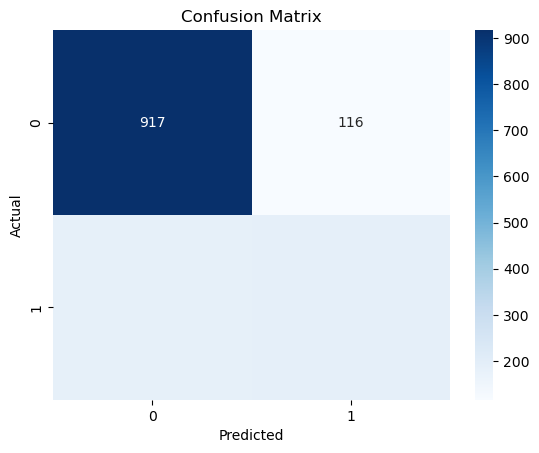

In [12]:
# Confusion Matrix dekho
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

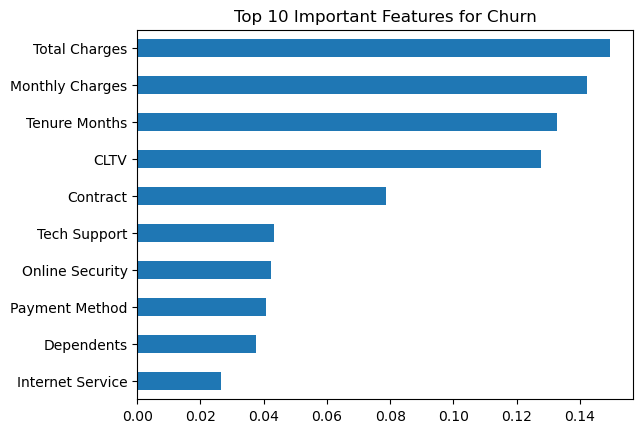

In [13]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Important Features for Churn')
plt.gca().invert_yaxis()
plt.show()

In [14]:
# Pura predictions full dataset (df_model) pe lagao
df_model['Churn_Predicted'] = model.predict(X)
df_model['Churn_Probability'] = model.predict_proba(X)[:, 1]

# Original readable columns (jo encode nahi hue, jaise Contract name) wapas join karo
# taaki Power BI mein labels readable rahein, sirf numbers na ho
export_df = df.loc[df_model.index, ['CustomerID', 'Gender', 'Senior Citizen', 'Partner', 
                                      'Dependents', 'Tenure Months', 'Contract', 
                                      'Internet Service', 'Payment Method', 
                                      'Monthly Charges', 'Total Charges', 'Churn Label']].copy()

export_df['Churn_Predicted'] = df_model['Churn_Predicted'].values
export_df['Churn_Probability'] = df_model['Churn_Probability'].values

export_df.to_csv('churn_results.csv', index=False)
print("Saved! Shape:", export_df.shape)

Saved! Shape: (7032, 14)


In [15]:
import os
print(os.getcwd())
print(os.path.exists('churn_results.csv'))

C:\Users\Dell
True


In [16]:
export_df.to_csv(r'C:\Users\Dell\Desktop\churn_results.csv', index=False)

In [1]:
import os
print(os.getcwd())

C:\Users\Dell


In [2]:
import os
print(os.getcwd())

C:\Users\Dell
